In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Exam_Score_Prediction.csv')

In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(20000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


### Dropping Unnecessary Columns
We will drop the `student_id` column as it is an identifier and does not contribute to predicting the exam score.

In [ ]:
if 'student_id' in df.columns:
    df = df.drop(columns=['student_id'])
display(df.head())

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### Target Variable Analysis: Exam Score Distribution
Let's analyze the distribution of our target variable `exam_score`.

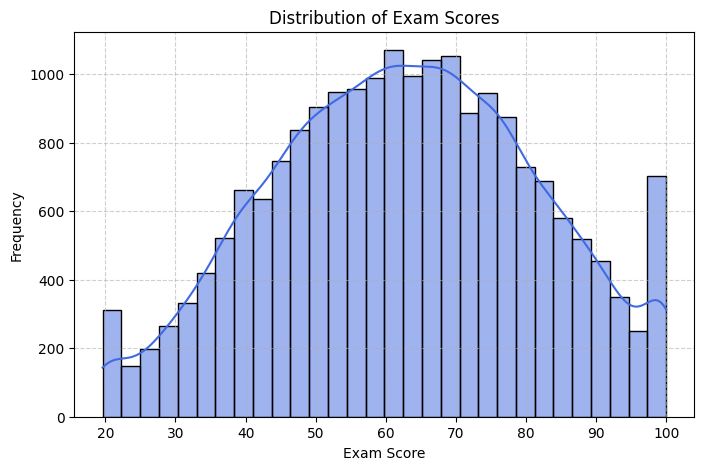

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Relationship of Numerical Features with Exam Score
Let's examine how continuous numerical variables like `study_hours`, `class_attendance`, `sleep_hours`, and `age` correlate with and affect `exam_score`.

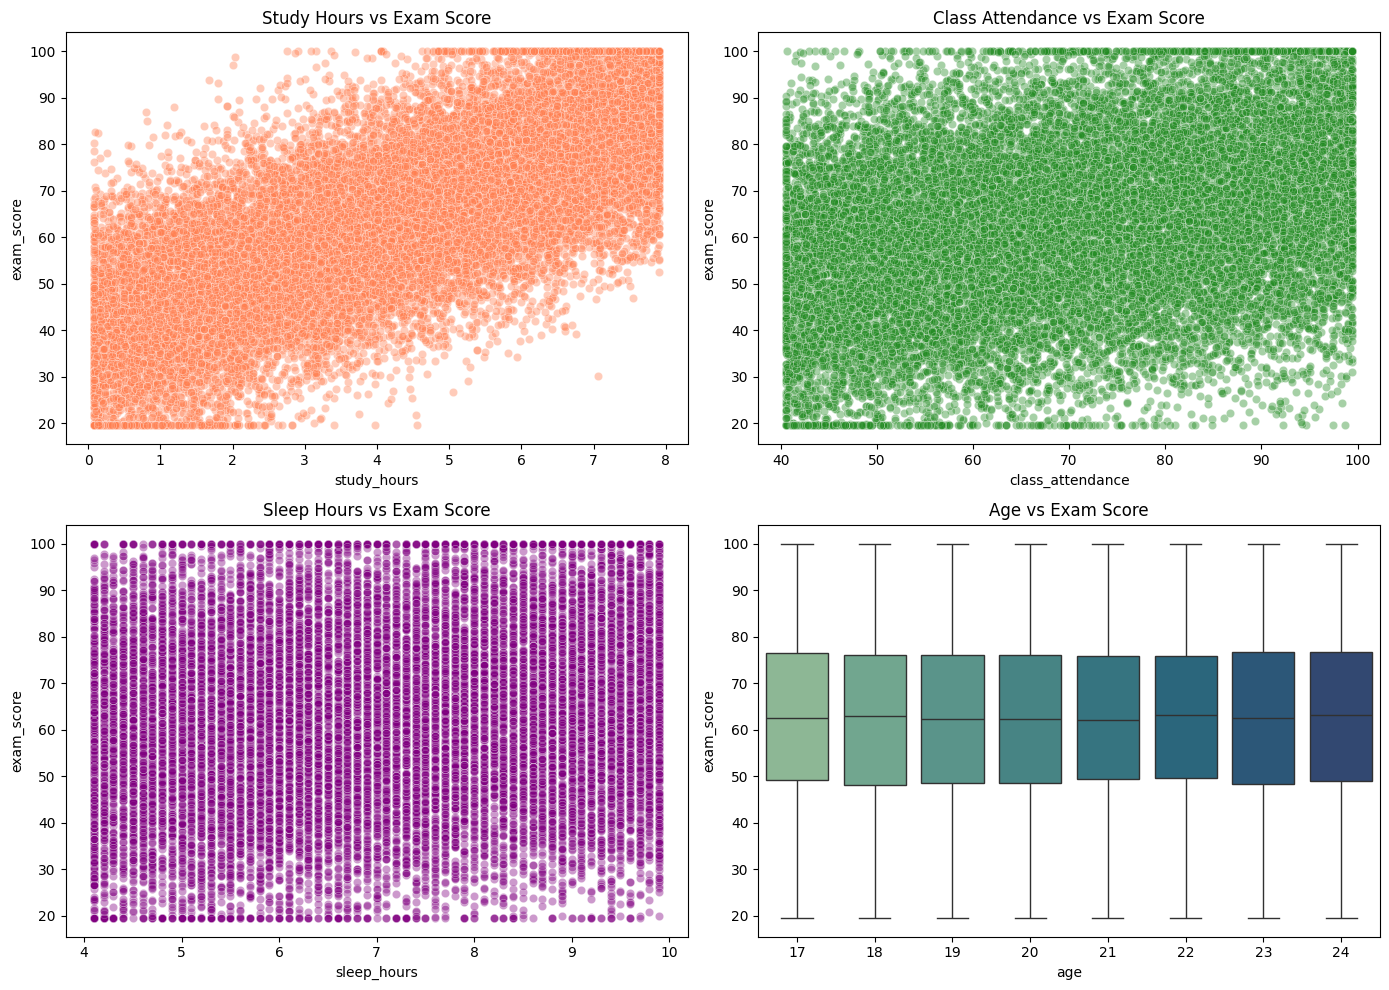

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='study_hours', y='exam_score', alpha=0.4, ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Study Hours vs Exam Score')

sns.scatterplot(data=df, x='class_attendance', y='exam_score', alpha=0.4, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Class Attendance vs Exam Score')

sns.scatterplot(data=df, x='sleep_hours', y='exam_score', alpha=0.4, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Sleep Hours vs Exam Score')

sns.boxplot(data=df, x='age', y='exam_score', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Age vs Exam Score')

plt.tight_layout()
plt.show()

### Relationship of Categorical Features with Exam Score
Let's explore how categorical variables like `gender`, `internet_access`, `sleep_quality`, `study_method`, `facility_rating`, and `exam_difficulty` affect the average `exam_score`.

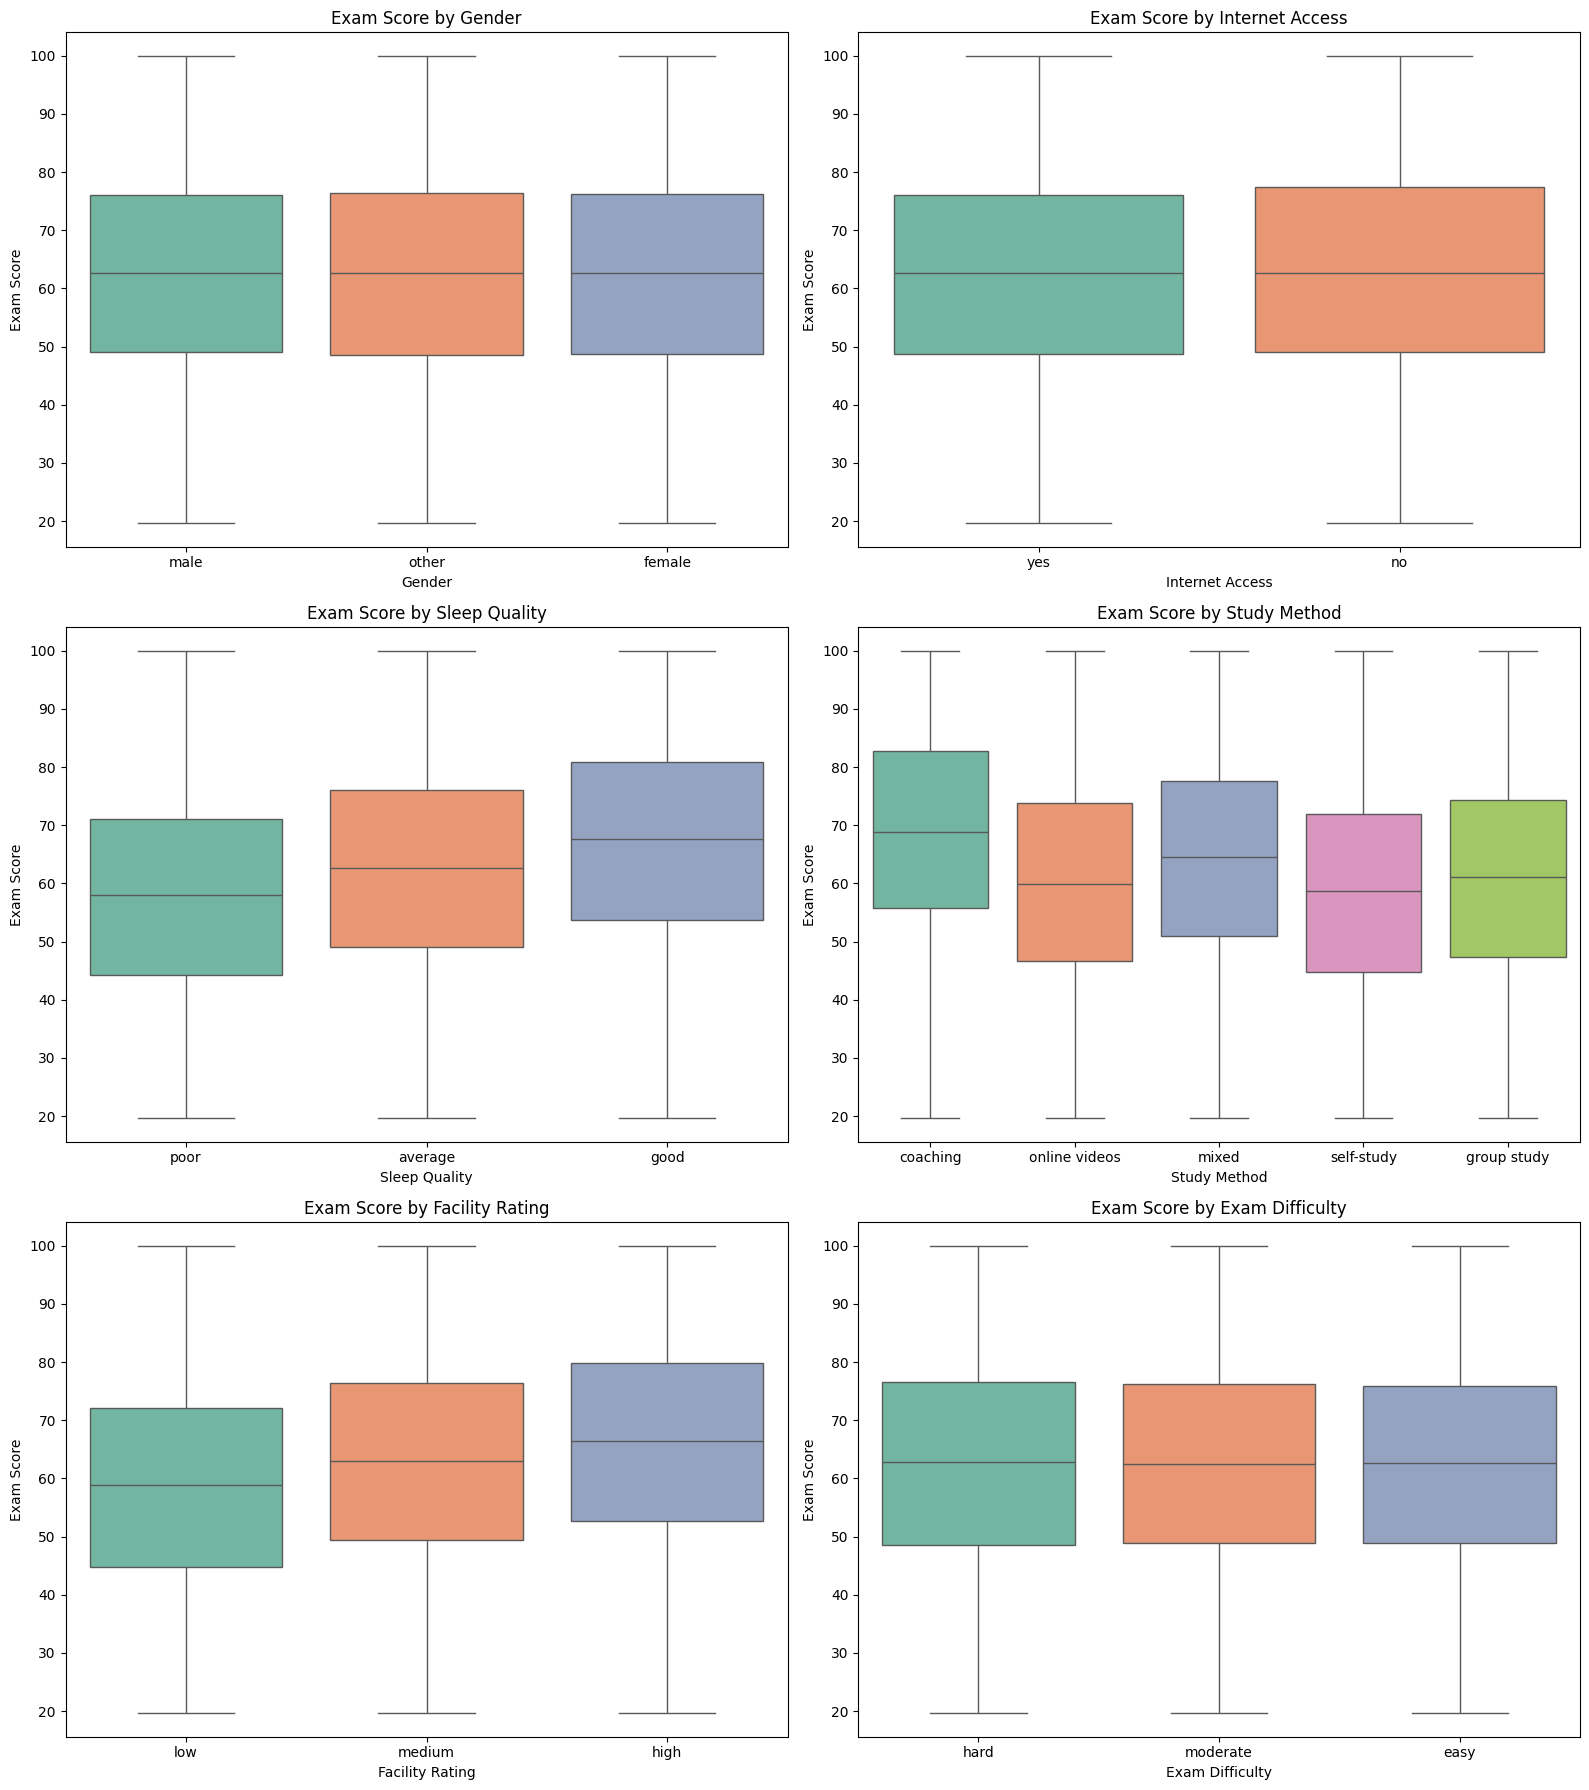

In [ ]:
categorical_cols = ['gender', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Exam Score by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

### Correlation Heatmap
Let's plot a correlation matrix of our numerical features to understand how strongly they are linearly related to `exam_score`.

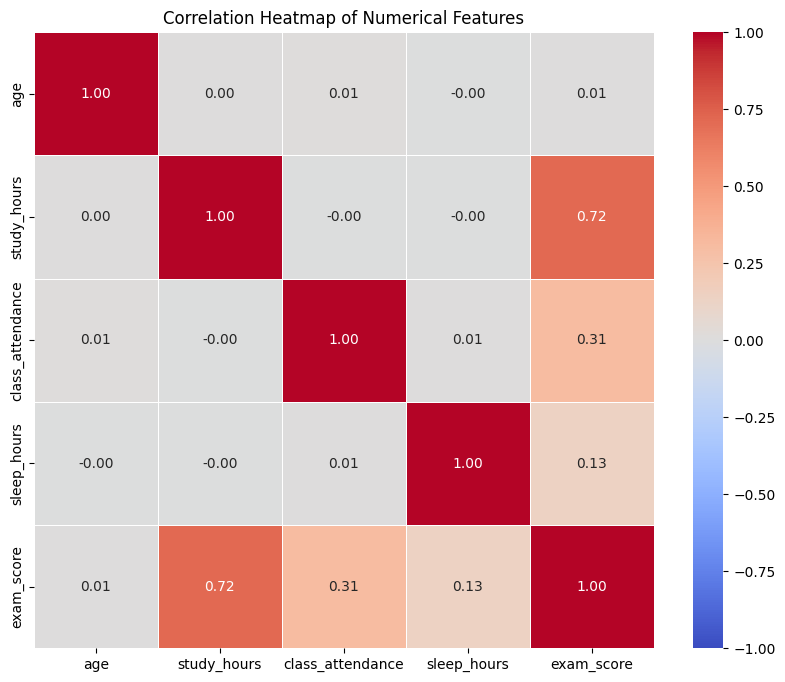

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## EDA Summary Findings

Based on our Exploratory Data Analysis on the **Exam Score Prediction** dataset, here are the key insights and takeaways with respect to predicting `exam_score`:

### 1. Target Variable (`exam_score`)
* The distribution of `exam_score` is roughly bell-shaped (approximately normal), centered around a mean score, with a clean variance spanning from low to high grades.

### 2. Primary Numerical Predictors
* **Study Hours (`0.72` correlation):** This is the strongest linear predictor of the exam score. As expected, a higher number of hours spent studying is strongly and positively correlated with higher exam results.
* **Class Attendance (`0.31` correlation):** This has a moderate positive correlation. Higher attendance rates are consistently associated with higher exam scores.
* **Sleep Hours (`0.13` correlation):** Shows a weak but positive relationship. Adequate sleep has a minor positive influence on the final outcomes.
* **Age (`0.01` correlation):** Age shows virtually no linear correlation with exam scores, suggesting that student age is not a primary differentiator for performance within this dataset.

### 3. Categorical Influences
* **Exam Difficulty:** Students taking harder exams generally score lower, showing a noticeable shift in the median score between easy/moderate and hard levels.
* **Study Method:** Different study methods (such as coaching, self-study, or online videos) show variation in performance distributions, which might serve as a strong feature for our predictive model.
* **Sleep Quality and Internet Access:** Positive sleep quality and having internet access correlate with slightly higher median exam outcomes.
* **Gender and Facility Rating:** These features show relatively stable medians across groups, suggesting they might have less individual impact, although interaction effects are possible during model training.

### Statistical Testing (One-Way ANOVA)
To confirm whether the categorical variables (and `age`) have a statistically significant relationship with the target variable `exam_score`, we can perform a One-Way ANOVA (F-test) for each feature. This tests the null hypothesis that the mean `exam_score` is the same across all groups of a given category.

In [ ]:
import scipy.stats as stats

# Define the list of categorical variables to test, including 'age'
categorical_to_test = ['age', 'gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

anova_results = []

for col in categorical_to_test:
    # Group the exam scores by the unique categories of each variable
    groups = [group['exam_score'].values for name, group in df.groupby(col)]

    # Perform One-way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)

    anova_results.append({
        'Feature': col,
        'F-Statistic': f_stat,
        'p-value': p_val,
        'Significant (alpha=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

# Create a DataFrame to display results
anova_df = pd.DataFrame(anova_results).sort_values(by='F-Statistic', ascending=False)
display(anova_df)

,Feature,F-Statistic,p-value,Significant (alpha=0.05)
4,sleep_quality,411.793336,5.560728e-176,Yes
6,facility_rating,273.766437,5.050711e-118,Yes
5,study_method,180.526693,3.198667e-152,Yes
3,internet_access,1.224987,2.683976e-01,No
2,course,0.614432,7.189976e-01,No
0,age,0.314983,9.476259e-01,No
7,exam_difficulty,0.236966,7.890206e-01,No
1,gender,0.190609,8.264568e-01,No


0   age               20000 non-null  int64 ❌


 1   gender            20000
 non-null  object ❌

 2   course            20000 non-null  object ⏫

 3   study_hours       20000 non-null  float64 ✅

 4   class_attendance  20000 non-null  float64 ✅

 5   internet_access   20000 non-null  object ❌

 6   sleep_hours       20000 non-null  float64 ✅

 7   sleep_quality     20000 non-null  object ✅

 8   study_method      20000 non-null  object ✅

 9   facility_rating   20000 non-null  object ✅

 10  exam_difficulty   20000 non-null  object ❌

 11  exam_score        20000 non-null  float64 ✅


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

### Label Encoding Categorical Features
Now we will encode our categorical columns using `LabelEncoder`. This converts categories into numeric integers.

In [ ]:
# Identify categorical columns (excluding numerical columns and the target variable)
categorical_cols_to_encode = df.select_dtypes(include=['object']).columns.tolist()

# Instantiate and apply LabelEncoder to each categorical column
encoded_mappings = {}
for col in categorical_cols_to_encode:
    df[col] = le.fit_transform(df[col])
    # Store mappings for reference
    encoded_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the encoded column mappings
for col, mapping in encoded_mappings.items():
    print(f"{col} mappings: {mapping}")

# Verify changes
display(df.head())

gender mappings: {'female': np.int64(0), 'male': np.int64(1), 'other': np.int64(2)}
course mappings: {'b.com': np.int64(0), 'b.sc': np.int64(1), 'b.tech': np.int64(2), 'ba': np.int64(3), 'bba': np.int64(4), 'bca': np.int64(5), 'diploma': np.int64(6)}
internet_access mappings: {'no': np.int64(0), 'yes': np.int64(1)}
sleep_quality mappings: {'average': np.int64(0), 'good': np.int64(1), 'poor': np.int64(2)}
study_method mappings: {'coaching': np.int64(0), 'group study': np.int64(1), 'mixed': np.int64(2), 'online videos': np.int64(3), 'self-study': np.int64(4)}
facility_rating mappings: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
exam_difficulty mappings: {'easy': np.int64(0), 'hard': np.int64(1), 'moderate': np.int64(2)}


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


In [ ]:
X=df.drop(['exam_score','age','gender','internet_access','exam_difficulty','course'],axis=1)
y=df['exam_score']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


### Training the Decision Tree Regressor
Let's instantiate the Decision Tree Regressor, fit it with our training set, and evaluate its prediction performance using MSE, RMSE, MAE, and $R^2$ scores.

In [ ]:
# Initialize the Decision Tree Regressor model with a set random state
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the model on training data
dt_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = dt_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the performance metrics
print("Decision Tree Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score (Coefficient of Determination): {r2:.4f}")

Decision Tree Regressor Performance Metrics:
Mean Absolute Error (MAE): 11.7722
Mean Squared Error (MSE): 218.0949
Root Mean Squared Error (RMSE): 14.7680
R2 Score (Coefficient of Determination): 0.3903


In [ ]:
from sklearn.ensemble import AdaBoostRegressor


### Training AdaBoost Regressor
Let's train an `AdaBoostRegressor` using default parameters on our split dataset and compare its performance metrics (MAE, MSE, RMSE, $R^2$) to the Decision Tree model.

In [ ]:
# Initialize the AdaBoost Regressor model
ada_model = AdaBoostRegressor(random_state=42)

# Fit the model on training data
ada_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_ada = ada_model.predict(X_test)

# Calculate evaluation metrics
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

# Print the performance metrics
print("AdaBoost Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_ada:.4f}")
print(f"Mean Squared Error (MSE): {mse_ada:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ada:.4f}")
print(f"R2 Score (Coefficient of Determination): {r2_ada}")

AdaBoost Regressor Performance Metrics:
Mean Absolute Error (MAE): 8.8908
Mean Squared Error (MSE): 118.1829
Root Mean Squared Error (RMSE): 10.8712
R2 Score (Coefficient of Determination): 0.6696005392708153


### Training XGBoost Regressor
Let's import `xgboost` and train an `XGBRegressor` on our dataset to see if gradient boosting can further improve performance over AdaBoost and the Decision Tree model.

In [ ]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor model
xgb_model = XGBRegressor(random_state=42)

# Fit the model on training data
xgb_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print the performance metrics
print("XGBoost Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R2 Score (Coefficient of Determination): {r2_xgb:.4f}")

XGBoost Regressor Performance Metrics:
Mean Absolute Error (MAE): 8.3566
Mean Squared Error (MSE): 108.3619
Root Mean Squared Error (RMSE): 10.4097
R2 Score (Coefficient of Determination): 0.6971


### Hyperparameter Tuning for XGBoost using GridSearchCV
Let's perform a grid search to find the optimal combination of parameters (`max_depth`, `learning_rate`, and `n_estimators`) for our `XGBRegressor` model to improve the test performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define the updated hyperparameter grid with gamma, subsample, and colsample_bytree
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.7,0.8,0.9, 1.0],
    'colsample_bytree': [0.7,0.8,0.9, 1.0]
}

# Initialize the base XGBoost model
xgb_base = XGBRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Extract the best model and parameters
best_xgb_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Parameters Found:")
print(best_params)

# Predict using the best model on test data
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Calculate and display the metrics for the optimized model
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("\nOptimized XGBoost Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_best_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_best_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_xgb:.4f}")
print(f"R2 Score (Coefficient of Determination): {r2_best_xgb:.4f}")

Fitting 3 folds for each of 864 candidates, totalling 2592 fits
Best Parameters Found:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}

Optimized XGBoost Regressor Performance Metrics:
Mean Absolute Error (MAE): 7.9583
Mean Squared Error (MSE): 97.1228
Root Mean Squared Error (RMSE): 9.8551
R2 Score (Coefficient of Determination): 0.7285


### Training and Evaluating the Final Tuned XGBoost Regressor
We will now train the final XGBoost Regressor on the complete training set using the optimal hyperparameters found from our grid search and evaluate its performance on the test set.

In [ ]:
# Instantiate the final XGBoost Regressor with the best found hyperparameters
final_xgb_model = XGBRegressor(
    **best_params,
    random_state=42
)

# Train the model on training data
final_xgb_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_final = final_xgb_model.predict(X_test)

# Calculate final metrics
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

# Display the final optimized performance metrics
print("Final Tuned XGBoost Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_final:.4f}")
print(f"Mean Squared Error (MSE): {mse_final:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_final:.4f}")
print(f"R2 Score (Coefficient of Determination): {r2_final}")

Final Tuned XGBoost Regressor Performance Metrics:
Mean Absolute Error (MAE): 7.9583
Mean Squared Error (MSE): 97.1228
Root Mean Squared Error (RMSE): 9.8551
R2 Score (Coefficient of Determination): 0.7284775154372595


### Properly Saving Unique LabelEncoders and the Final Model
Instead of a single `le` instance that only remembers the last encoded column, we will create, fit, and save a dictionary of separate `LabelEncoder` instances for each categorical feature. This ensures correct preprocessing when reusing the model on unseen data.

In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

# 1. Reload the original dataset to reconstruct correct, isolated encoders
original_df = pd.read_csv('Exam_Score_Prediction.csv')
if 'student_id' in original_df.columns:
    original_df = original_df.drop(columns=['student_id'])

categorical_cols_to_encode = original_df.select_dtypes(include=['object']).columns.tolist()

# 2. Fit and store a dedicated LabelEncoder for each categorical column
label_encoders = {}
for col in categorical_cols_to_encode:
    le_col = LabelEncoder()
    original_df[col] = le_col.fit_transform(original_df[col])
    label_encoders[col] = le_col

# 3. Align features to what our model expects
X_temp = original_df.drop(['exam_score', 'age', 'gender', 'internet_access', 'exam_difficulty', 'course'], axis=1)
y_temp = original_df['exam_score']

# 4. Fit the final model with best parameters on the full dataset to ensure maximum learning
final_xgb_model = XGBRegressor(
    colsample_bytree=0.7,
    gamma=0,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    subsample=0.7,
    random_state=42
)
final_xgb_model.fit(X_temp, y_temp)

# 5. Export the dictionary of LabelEncoders and the model
with open('label_encoders_dict.pkl', 'wb') as le_file:
    pickle.dump(label_encoders, le_file)

with open('final_xgb_model.pkl', 'wb') as model_file:
    pickle.dump(final_xgb_model, model_file)

print("Successfully saved 'label_encoders_dict.pkl' (containing individual encoders for each column) and 'final_xgb_model.pkl'!")

### Exporting the Preprocessing LabelEncoder and Final Model
We will use Python's built-in `pickle` library to save the `LabelEncoder` instance and our optimized `final_xgb_model` so they can be easily loaded and reused in other environments or applications.

In [ ]:
import pickle

# Save the LabelEncoder instance
from sklearn.preprocessing import LabelEncoder
import pickle

categorical_columns = [
    "sleep_quality",
    "study_method",
    "facility_rating"
]

encoders_dict = {}

for column in categorical_columns:

    le = LabelEncoder()

    df[column] = le.fit_transform(df[column])

    encoders_dict[column] = le


# Save all encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders_dict, f)

# Save the final tuned XGBoost Regressor model
with open('final_xgb_model.pkl', 'wb') as model_file:
    pickle.dump(final_xgb_model, model_file)

print("Successfully saved 'label_encoder.pkl' and 'final_xgb_model.pkl'!")

Successfully saved 'label_encoder.pkl' and 'final_xgb_model.pkl'!


```markdown
## Requirements File Generation

Run the cell below to automatically write the `requirements.txt` file in your workspace.
```